Explainable Transformer Based Framework for Early Detection of Mental Health Disorders from Social Media Text

---

### imports and paths

In [1]:
import pickle, json
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
from xgboost import XGBClassifier

TFIDF      = Path('..') / 'datasets' / 'processed' / 'tfidf'
SPLITS     = Path('..') / 'datasets' / 'processed' / 'splits'
MODELS_DIR = Path('..') / 'models' / 'saved'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SAVE_THRESHOLD = 0.75   # only save if macro-F1 on test >= this

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})
print('models will be saved to:', MODELS_DIR.resolve())

models will be saved to: /Users/muhammadusman/Desktop/final theisis 2026/Miraj/data/models/saved


---

### load features and labels

In [2]:
X_train = sp.load_npz(str(TFIDF / 'X_train.npz'))
X_val   = sp.load_npz(str(TFIDF / 'X_val.npz'))
X_test  = sp.load_npz(str(TFIDF / 'X_test.npz'))

y_train = np.load(str(TFIDF / 'y_train.npy'))
y_val   = np.load(str(TFIDF / 'y_val.npy'))
y_test  = np.load(str(TFIDF / 'y_test.npy'))

with open(SPLITS / 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
CLASS_NAMES = list(le.classes_)

print(f'train: {X_train.shape}  val: {X_val.shape}  test: {X_test.shape}')
print('classes:', CLASS_NAMES)

train: (33159, 50000)  val: (7106, 50000)  test: (7106, 50000)
classes: ['Anxiety/Stress', 'Bipolar', 'Depression', 'Normal', 'Suicidal']


### helper — evaluate and plot

In [3]:
def evaluate(name, model, X, y, split='test'):
    preds = model.predict(X)
    acc   = accuracy_score(y, preds)
    f1    = f1_score(y, preds, average='macro')
    print(f'\n{name} — {split}')
    print(f'  accuracy : {acc:.4f}')
    print(f'  macro-F1 : {f1:.4f}')
    print(classification_report(y, preds, target_names=CLASS_NAMES, digits=3))
    return acc, f1


def plot_confusion(name, model, X, y):
    preds = model.predict(X)
    cm    = confusion_matrix(y, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} — confusion matrix (normalised, test set)')
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

---

### logistic regression

In [4]:
print('training logistic regression ...')
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    n_jobs=-1,
    random_state=42,
)
lr.fit(X_train, y_train)
print('done')

training logistic regression ...


/Users/muhammadusman/Desktop/final theisis 2026/Miraj/data/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


done


In [5]:
lr_val_acc,  lr_val_f1  = evaluate('Logistic Regression', lr, X_val,  y_val,  'val')
lr_test_acc, lr_test_f1 = evaluate('Logistic Regression', lr, X_test, y_test, 'test')


Logistic Regression — val
  accuracy : 0.7672
  macro-F1 : 0.7651
                precision    recall  f1-score   support

Anxiety/Stress      0.746     0.822     0.782       873
       Bipolar      0.735     0.800     0.766       375
    Depression      0.772     0.645     0.703      2252
        Normal      0.860     0.922     0.890      2015
      Suicidal      0.664     0.706     0.684      1591

      accuracy                          0.767      7106
     macro avg      0.755     0.779     0.765      7106
  weighted avg      0.767     0.767     0.765      7106


Logistic Regression — test
  accuracy : 0.7670
  macro-F1 : 0.7727
                precision    recall  f1-score   support

Anxiety/Stress      0.779     0.820     0.799       874
       Bipolar      0.762     0.845     0.802       375
    Depression      0.757     0.650     0.699      2252
        Normal      0.862     0.912     0.887      2014
      Suicidal      0.654     0.701     0.677      1591

      accuracy      

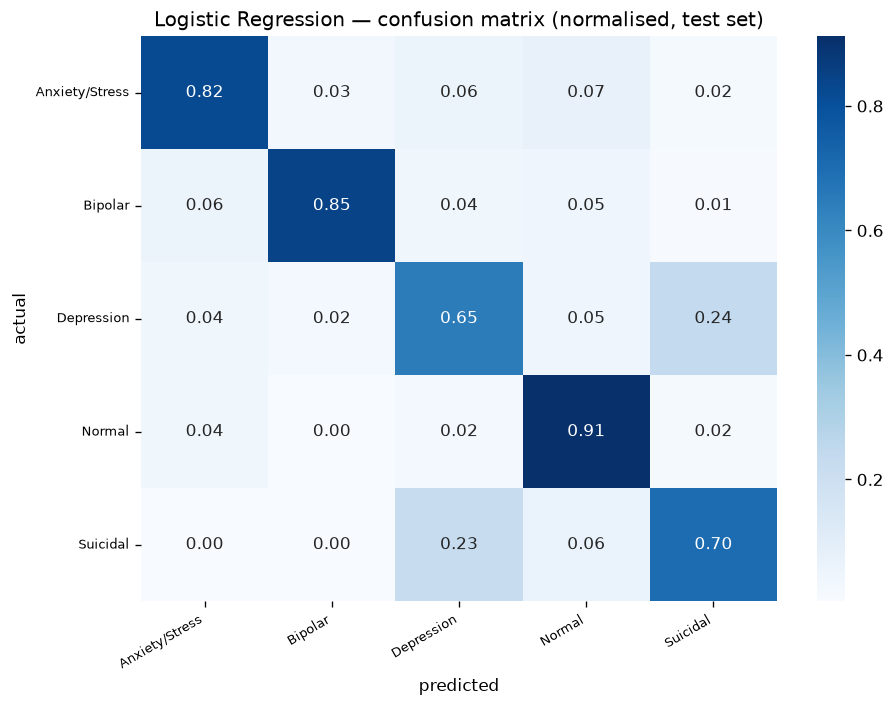

In [6]:
plot_confusion('Logistic Regression', lr, X_test, y_test)

In [7]:
if lr_test_f1 >= SAVE_THRESHOLD:
    path = MODELS_DIR / 'logistic_regression.pkl'
    with open(path, 'wb') as f:
        pickle.dump(lr, f)
    print(f'saved → {path}  (macro-F1 {lr_test_f1:.4f} >= {SAVE_THRESHOLD})')
else:
    print(f'NOT saved — macro-F1 {lr_test_f1:.4f} below threshold {SAVE_THRESHOLD}')

saved → ../models/saved/logistic_regression.pkl  (macro-F1 0.7727 >= 0.75)


---

### xgboost

In [8]:
# compute per-class weights to handle imbalance
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

print('training xgboost ...')
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.3,
    objective='multi:softprob',
    num_class=len(CLASS_NAMES),
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    # hist method is far faster than exact on large sparse feature spaces
    tree_method='hist',
    device='cpu',
    n_jobs=-1,
    random_state=42,
    verbosity=0,
)
xgb.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=50,
)
print(f'done — best iteration: {xgb.best_iteration}')

training xgboost ...


[0]	validation_0-mlogloss:1.55651


[50]	validation_0-mlogloss:0.81019


[100]	validation_0-mlogloss:0.70266


[150]	validation_0-mlogloss:0.65981


[200]	validation_0-mlogloss:0.63495


[250]	validation_0-mlogloss:0.61764


[299]	validation_0-mlogloss:0.60601


done — best iteration: 299


In [9]:
xgb_val_acc,  xgb_val_f1  = evaluate('XGBoost', xgb, X_val,  y_val,  'val')
xgb_test_acc, xgb_test_f1 = evaluate('XGBoost', xgb, X_test, y_test, 'test')


XGBoost — val
  accuracy : 0.7636
  macro-F1 : 0.7641


                precision    recall  f1-score   support

Anxiety/Stress      0.739     0.837     0.785       873
       Bipolar      0.768     0.787     0.777       375
    Depression      0.775     0.637     0.699      2252
        Normal      0.853     0.922     0.886      2015
      Suicidal      0.650     0.696     0.673      1591

      accuracy                          0.764      7106
     macro avg      0.757     0.776     0.764      7106
  weighted avg      0.764     0.764     0.761      7106


XGBoost — test
  accuracy : 0.7720
  macro-F1 : 0.7747
                precision    recall  f1-score   support

Anxiety/Stress      0.756     0.852     0.802       874
       Bipolar      0.772     0.811     0.791       375
    Depression      0.789     0.651     0.713      2252
        Normal      0.856     0.911     0.883      2014
      Suicidal      0.659     0.714     0.685      1591

      accuracy                          0.772      7106
     macro avg      0.766     0.788     0.7

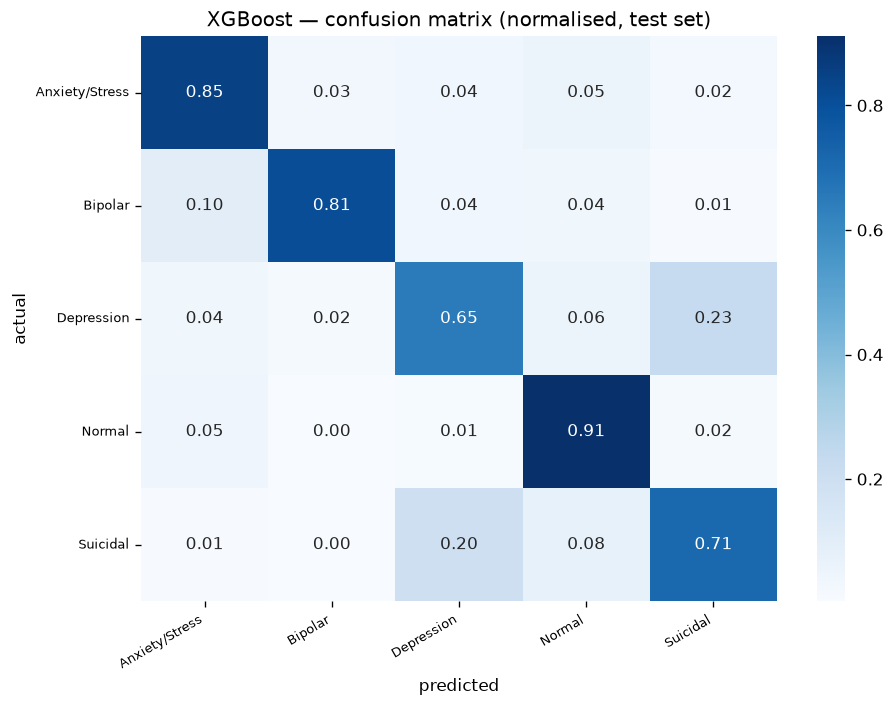

In [10]:
plot_confusion('XGBoost', xgb, X_test, y_test)

In [11]:
if xgb_test_f1 >= SAVE_THRESHOLD:
    path = MODELS_DIR / 'xgboost.json'
    xgb.save_model(str(path))
    print(f'saved → {path}  (macro-F1 {xgb_test_f1:.4f} >= {SAVE_THRESHOLD})')
else:
    print(f'NOT saved — macro-F1 {xgb_test_f1:.4f} below threshold {SAVE_THRESHOLD}')

saved → ../models/saved/xgboost.json  (macro-F1 0.7747 >= 0.75)


---

### comparison


ML model comparison (test set):
                     accuracy  macro_f1
Logistic Regression     0.767    0.7727
XGBoost                 0.772    0.7747


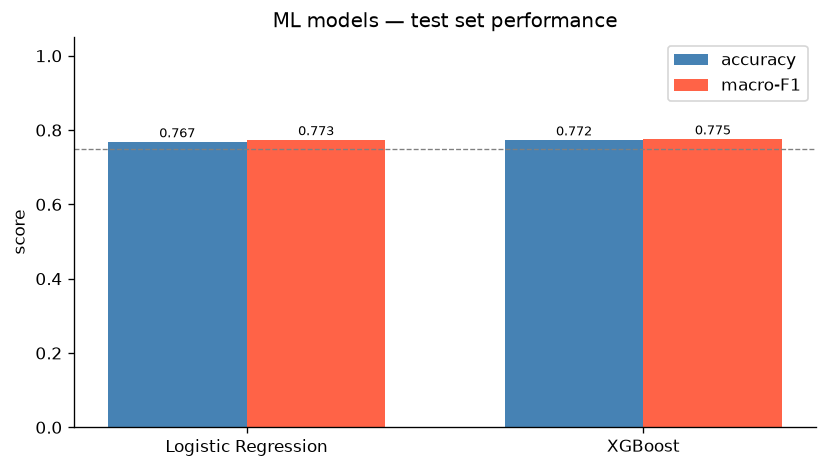

results saved to ml_results.json


In [12]:
import pandas as pd

results = {
    'Logistic Regression': {'accuracy': lr_test_acc,  'macro_f1': lr_test_f1},
    'XGBoost':             {'accuracy': xgb_test_acc, 'macro_f1': xgb_test_f1},
}

res_df = pd.DataFrame(results).T.round(4)
print('\nML model comparison (test set):')
print(res_df.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(results))
w = 0.35
ax.bar(x - w/2, [v['accuracy'] for v in results.values()], w, label='accuracy', color='steelblue')
ax.bar(x + w/2, [v['macro_f1'] for v in results.values()], w, label='macro-F1', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(list(results.keys()))
ax.set_ylim(0, 1.05)
ax.set_ylabel('score')
ax.set_title('ML models — test set performance')
ax.legend()
ax.axhline(SAVE_THRESHOLD, color='gray', linestyle='--', linewidth=0.8, label=f'threshold {SAVE_THRESHOLD}')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# save results for the final comparison notebook
with open(MODELS_DIR / 'ml_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('results saved to ml_results.json')

---

### save charts and classification reports to results/

In [13]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path

RESULTS_DIR = Path('..') / 'results'
CHARTS_DIR  = RESULTS_DIR / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)


def save_confusion(name, model, X, y):
    preds  = model.predict(X)
    cm     = confusion_matrix(y, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} — confusion matrix (normalised, test set)')
    ax.set_xlabel('predicted'); ax.set_ylabel('actual')
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    fname = name.lower().replace(' ', '_')
    fig.savefig(CHARTS_DIR / f'confusion_{fname}.png', bbox_inches='tight')
    plt.close(fig)

    # save classification report as CSV
    report = classification_report(y, preds, target_names=CLASS_NAMES,
                                   output_dict=True)
    pd.DataFrame(report).T.round(3).to_csv(RESULTS_DIR / f'classification_report_{fname}.csv')
    print(f'saved: charts/confusion_{fname}.png + results/classification_report_{fname}.csv')


save_confusion('Logistic Regression', lr,  X_test, y_test)
save_confusion('XGBoost',             xgb, X_test, y_test)
print('done')

saved: charts/confusion_logistic_regression.png + results/classification_report_logistic_regression.csv


saved: charts/confusion_xgboost.png + results/classification_report_xgboost.csv
done
